<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Створення нейронної мережі

У цьому завданні ми створимо повнозв'язну нейронну мережу, використовуючи при цьому низькорівневі механізми tensorflow.

Архітектура нейромережі представлена на наступному малюнку. Як бачиш, у ній є один вхідний шар, два приховані, а також вихідний шар. В якості активаційної функції у прихованих шарах буде використовуватись сигмоїда. На вихідному шарі ми використовуємо softmax.

Частина коду зі створення мережі вже написана, тобі потрібно заповнити пропуски у вказаних місцях.

## Архітектура нейронної мережі

<img src="http://cs231n.github.io/assets/nn1/neural_net2.jpeg" alt="nn" style="width: 400px;"/>


## Про датасет MNIST

Дану нейромережу ми будемо вивчати на датасеті MNIST. Цей датасет являє собою велику кількість зображень рукописних цифр розміром $28 \times 28$ пікселів. Кожен піксель приймає значення від 0 до 255.

Як і раніше, датасет буде розділений на навчальну та тестову вибірки. При цьому ми виконаємо нормалізацію всіх зображень, щоб значення пікселів знаходилось у проміжку від 0 до 1, розділивши яскравість кожного пікселя на 255.

Окрім того, архітектура нейронної мережі очікує на вхід вектор. У нашому ж випадку кожен об'єкт вибірки являє собою матрицю. Що ж робити? У цьому завданні ми "розтягнемо" матрицю $28 \times 28$, отримавши при цьому вектор, що складається з 784 елементів.

![MNIST Dataset](https://www.researchgate.net/profile/Steven-Young-5/publication/306056875/figure/fig1/AS:393921575309346@1470929630835/Example-images-from-the-MNIST-dataset.png)

Більше інформації про датасет можна знайти [тут](http://yann.lecun.com/exdb/mnist/).

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import keras as K
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [2]:
num_classes = 10 # загальна кількість класів, у нашому випадку це цифри від 0 до 9
num_features = 784 # кількість атрибутів вхідного вектора 28 * 28 = 784

learning_rate = 0.001 # швидкість навчання нейронної мережі
training_steps = 3000 # максимальне число епох
batch_size = 256 # перераховувати ваги мережі ми будемо не на всій вибірці, а на її випадковій підмножині з batch_size елементів
display_step = 100 # кожні 100 ітерацій ми будемо показувати поточне значення функції втрат і точності

n_hidden_1 = 128 # кількість нейронів 1-го шару
n_hidden_2 = 256 # кількість нейронів 2-го шару

In [3]:
# from tensorflow.keras.datasets import mnist
from keras.datasets import mnist

# Завантажуємо датасет
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Перетворюємо цілочисельні пікселі на тип float32
x_train, x_test = np.array(x_train, np.float32), np.array(x_test, np.float32)

# Перетворюємо матриці розміром 28x28 пікселів у вектор з 784 елементів
x_train, x_test = x_train.reshape([-1, num_features]), x_test.reshape([-1, num_features])

# Нормалізуємо значення пікселів
x_train, x_test = x_train / 255., x_test / 255.

# Перемішаємо тренувальні дані
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.repeat().shuffle(5000).batch(batch_size).prefetch(1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Створимо нейронну мережу

class DenseLayer(tf.Module):
    def __init__(self, in_features, out_features, name=None):
        super().__init__(name=name)
        self.w = tf.Variable(
            tf.random.normal([in_features, out_features]), name="w"
        )
        self.b = tf.Variable(tf.zeros([out_features]), name="b")

    def __call__(self, x, activation=0):
        y = tf.matmul(x, self.w) + self.b
        if activation != 0:
            return tf.nn.softmax(y)
        else:
            return tf.nn.sigmoid(y)

class NN(tf.Module):
  def __init__(self, name=None):
    super().__init__(name=name)
    # Перший шар, який складається з 128 нейронів
    self.layer_1 = DenseLayer(in_features=num_features, out_features=n_hidden_1, name="layer_1")
    # Другий шар, який складається з 256 нейронів
    self.layer_2 = DenseLayer(in_features=n_hidden_1, out_features=n_hidden_2, name="layer_2")
    # Вихідний шар
    self.out_layer = DenseLayer(in_features=n_hidden_2, out_features=num_classes, name="out_layer")


  def __call__(self, x):
    # Передача даних через перші два шари та вихідний шар з функцією активації softmax
    x = self.layer_1(x, activation=0)

    x = self.layer_2(x, activation=0)

    output = self.out_layer(x, activation=1)

    return output

In [5]:
# В якості функції помилки в даному випадку зручно взяти крос-ентропію
def cross_entropy(y_pred, y_true):
    # Закодувати label в one hot vector
    y_true = tf.one_hot(y_true, depth=num_classes)

    # Значення передбачення, щоб уникнути помилки log(0).
    y_pred = tf.clip_by_value(y_pred, 1e-9, 1.)

    # Обчислення крос-ентропії
    return tf.reduce_mean(-tf.reduce_sum(y_true * tf.math.log(y_pred)))

# Як метрику якості використовуємо точність
def accuracy(y_pred, y_true):
    predicted_classes = tf.argmax(y_pred, axis=1)
    correct_prediction = tf.equal(predicted_classes, tf.cast(y_true, tf.int64))
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))


In [6]:
# Створимо екземпляр нейронної мережі
neural_net = NN(name="mnist")

# Функція навчання нейромережі
def train(neural_net, input_x, output_y):
  # Для налаштування вагів мережі будемо використовувати стохастичний градієнтний спуск
  optimizer = tf.optimizers.SGD(learning_rate)

  # Активація автоматичного диференціювання
  with tf.GradientTape() as g:
    pred = neural_net(input_x)
    loss = cross_entropy(pred, output_y)

    # Отримаємо список оптимізованих параметрів
    trainable_variables = neural_net.trainable_variables
    # Обчислимо за ними значення градієнта
    gradients = g.gradient(loss, trainable_variables)

    # Модифікуємо параметри
    optimizer.apply_gradients(zip(gradients, trainable_variables))

In [7]:
# Тренування мережі

loss_history = []  # кожні display_step кроків зберігай в цьому списку поточну помилку нейромережі
accuracy_history = [] # кожні display_step кроків зберігай в цьому списку поточну точність нейромережі

# У цьому циклі ми будемо проводити навчання нейронної мережі
# із тренувального датасета train_data вилучи випадкову підмножину, на якій
# відбудеться тренування. Використовуй метод take, доступний для тренувального датасета.
for step, (batch_x, batch_y) in enumerate(train_data.take(training_steps), 1):
    # Оновлюємо ваги нейронної мережі
    train(neural_net, batch_x, batch_y)

    if step % display_step == 0:
        pred = neural_net(batch_x)

        current_loss = cross_entropy(pred, batch_y).numpy()
        current_acc = accuracy(pred, batch_y).numpy()

        loss_history.append(current_loss)
        accuracy_history.append(current_acc)

        print(f"Step: {step}, Loss: {current_loss:.4f}, Accuracy: {current_acc:.4f}")


Step: 100, Loss: 313.5704, Accuracy: 0.7422
Step: 200, Loss: 266.9197, Accuracy: 0.7344
Step: 300, Loss: 159.9949, Accuracy: 0.8438
Step: 400, Loss: 191.2715, Accuracy: 0.8359
Step: 500, Loss: 125.2085, Accuracy: 0.8398
Step: 600, Loss: 161.2567, Accuracy: 0.8320
Step: 700, Loss: 112.6428, Accuracy: 0.8672
Step: 800, Loss: 90.4792, Accuracy: 0.8906
Step: 900, Loss: 93.8381, Accuracy: 0.8945
Step: 1000, Loss: 108.0487, Accuracy: 0.8945
Step: 1100, Loss: 79.7064, Accuracy: 0.8945
Step: 1200, Loss: 93.8611, Accuracy: 0.8984
Step: 1300, Loss: 115.2831, Accuracy: 0.8750
Step: 1400, Loss: 119.3984, Accuracy: 0.8828
Step: 1500, Loss: 86.4830, Accuracy: 0.9219
Step: 1600, Loss: 102.6557, Accuracy: 0.8633
Step: 1700, Loss: 72.4466, Accuracy: 0.9062
Step: 1800, Loss: 77.8505, Accuracy: 0.9102
Step: 1900, Loss: 63.9765, Accuracy: 0.9375
Step: 2000, Loss: 92.4322, Accuracy: 0.8906
Step: 2100, Loss: 82.2632, Accuracy: 0.9180
Step: 2200, Loss: 56.0579, Accuracy: 0.9219
Step: 2300, Loss: 54.8423, Acc

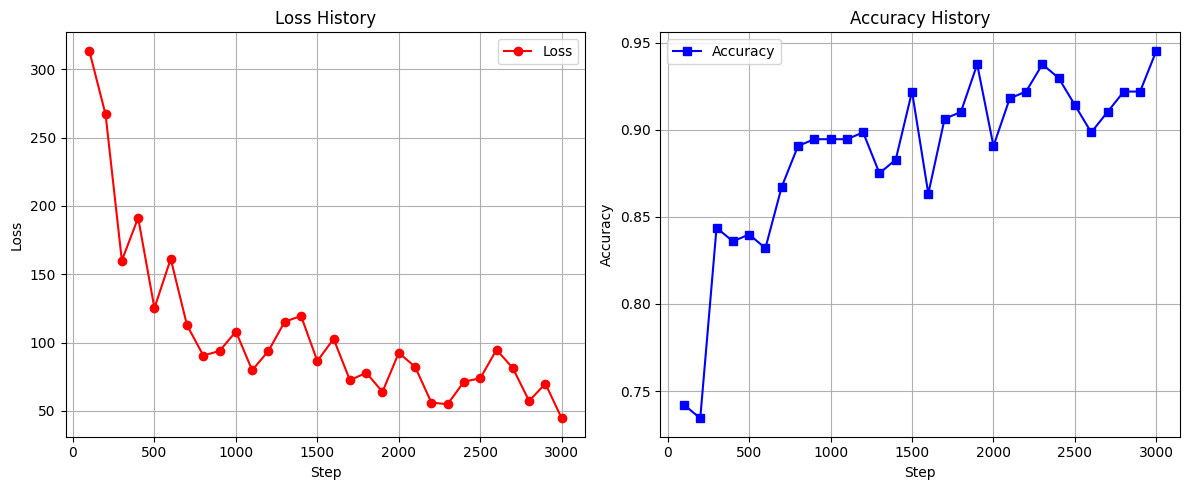

In [8]:
# Виведіть графіки залежності зміни точності і втрат від кроку
# Якщо все зроблено правильно, то точність повинна зростати, а втрати зменшуватись

import matplotlib.pyplot as plt

steps = list(range(display_step, training_steps + 1, display_step))

plt.figure(figsize=(12, 5))

# Виведіть графік функції втрат
plt.subplot(1, 2, 1)
plt.plot(steps, loss_history, color='red', marker='o', label='Loss')
plt.title('Loss History')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

# Виведіть графік точності
plt.subplot(1, 2, 2)
plt.plot(steps, accuracy_history, color='blue', marker='s', label='Accuracy')
plt.title('Accuracy History')
plt.xlabel('Step')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Обчисліть точність навченої нейромережі
# Тестування моделі на тестових даних
test_predictions = neural_net(x_test)
test_loss = cross_entropy(test_predictions, y_test).numpy()
test_accuracy = accuracy(test_predictions, y_test).numpy()

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 3157.6982
Test Accuracy: 0.9045


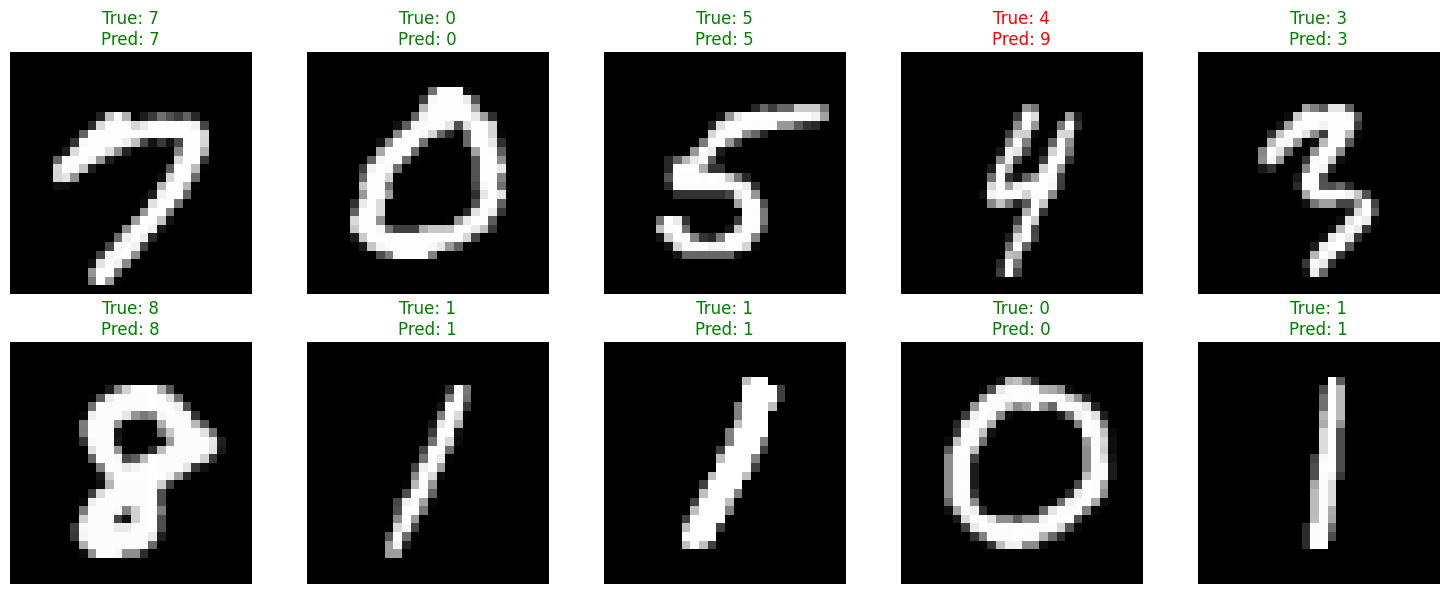

9 of 10 images


In [12]:
# Протестуйте навчену нейромережу на 10 зображеннях. З тестової вибірки візьміть 5
# випадкових зображень і передайте їх у нейронну мережу.
# Виведіть зображення та випишіть  поруч відповідь нейромережі.
# Зробіть висновок про те, чи помиляється твоя нейронна мережа, і якщо так, то як часто?

random_indices = random.sample(range(len(x_test)), 10)

plt.figure(figsize=(15, 6))
correct_count = 0

for i, idx in enumerate(random_indices):
    image_vector = x_test[idx]
    true_label = y_test[idx]

    prediction = neural_net(tf.expand_dims(image_vector, axis=0))
    predicted_label = tf.argmax(prediction, axis=1).numpy()[0]

    is_correct = predicted_label == true_label
    if is_correct:
        correct_count += 1

    image_matrix = image_vector.reshape(28, 28)

    plt.subplot(2, 5, i + 1)
    plt.imshow(image_matrix, cmap='gray')

    title_color = 'green' if is_correct else 'red'
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"{correct_count} of 10 images")

Висновок: у ході випадкового тестування на 10 зображеннях нейромережа продемонструвала високу точність, правильно розпізнавши більшість цифр (9).
Нейромережа може помилятися.
Оскільки загальна точність на тестовій вибірці  становить близько 90%, це означає, що мережа помиляється приблизно в 1–2 випадках з 10.

In [14]:
from sklearn.metrics import classification_report

test_predictions = neural_net(x_test)

y_pred_classes = np.argmax(test_predictions.numpy(), axis=1)

target_names = [f"Digit {i}" for i in range(num_classes)]

print(classification_report(y_test, y_pred_classes, target_names=target_names))

              precision    recall  f1-score   support

     Digit 0       0.94      0.97      0.95       980
     Digit 1       0.98      0.98      0.98      1135
     Digit 2       0.89      0.88      0.89      1032
     Digit 3       0.87      0.90      0.88      1010
     Digit 4       0.91      0.90      0.90       982
     Digit 5       0.88      0.84      0.86       892
     Digit 6       0.92      0.92      0.92       958
     Digit 7       0.92      0.90      0.91      1028
     Digit 8       0.86      0.86      0.86       974
     Digit 9       0.88      0.89      0.88      1009

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



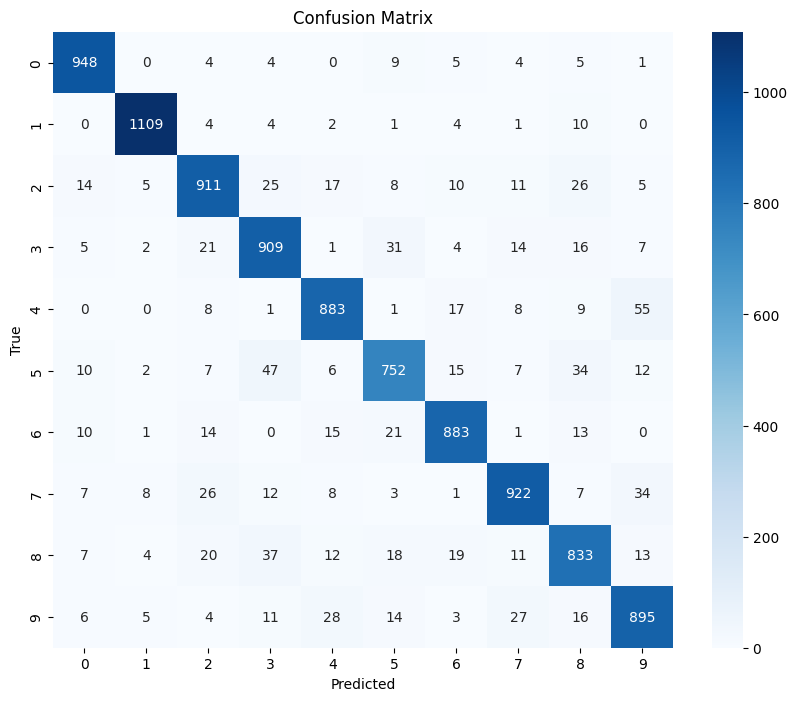

In [15]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()